In [16]:
import pandas as pd
import seaborn as sns

# Montare Google Drive nel notebook
from google.colab import drive
drive.mount('/content/drive')

# Definire il percorso del file
file_path = '/content/drive/MyDrive/italian_firms_cleaned_t3.csv'

# Caricare il dataset in un DataFrame di Pandas
try:
    df = pd.read_csv(file_path)
    print("Dataset caricato con successo!")
    print(f"Il dataset contiene {df.shape[0]} righe e {df.shape[1]} colonne.\n")
except FileNotFoundError:
    print("ERRORE: File non trovato. Controlla che il nome e il percorso su Google Drive siano corretti.")

# Visualizzare le prime righe per una prima occhiata ai dati
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset caricato con successo!
Il dataset contiene 43700 righe e 16 colonne.



,LN_TOTAL_ASSETS_t3,Current_liabilities/Tot_ass._t3,Solvency_ratio_t3,Debt/EBITDA_ratio_t3,Total_assets_turnover_(times)_t3,Durata_media_dei_crediti_al_lordo_IVA_(days)_t3,Return_on_asset_(ROA)_t3,Current_ratio_t3,LN_No_of_shareholders_t3,Independence_t3_B,Independence_t3_C,Independence_t3_D,Independence_t3_Missing,Area_Center,Area_South,Target
0,11.851504,1.00,5.98,13.30,0.49,26.76,0.25,1.00,0.693147,0,0,1,0,1,0,0
1,11.851504,0.45,49.99,13.30,0.34,20.74,-2.45,1.59,2.197225,1,0,0,0,1,0,0
2,11.851504,1.00,28.33,0.09,2.40,41.06,20.52,1.17,1.098612,0,0,1,0,1,0,0
3,11.851504,0.52,32.65,-0.23,0.84,7.01,-4.57,1.75,0.693147,0,1,0,0,0,0,0
4,11.851504,0.93,16.29,1.04,2.40,20.01,4.77,0.82,0.693147,0,0,1,0,1,0,0


In [17]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

# STEP PRELIMINARE: DEFINIZIONE DI X E y
target_column = 'Target'

# y è la variabile target (0 = sana, 1 = default)
y = df[target_column]

# X sono tutte le altre colonne
X = df.drop(columns=[target_column])

# SUDDIVISIONE E REGRESSIONE LOGISTICA
# Suddivisione del campione --> 70% Train, 30% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=== SUDDIVISIONE DEL CAMPIONE ===")
print(f"Aziende totali nel Training Set (70%): {X_train.shape[0]} (di cui default reali: {y_train.sum()})")
print(f"Aziende totali nel Test Set (30%): {X_test.shape[0]} (di cui default reali: {y_test.sum()})")
print("-" * 60)

# Convertiamo esplicitamente X_train in float per evitare qualsiasi attrito con statsmodels
X_train = X_train.astype(float)

# 2. Aggiungiamo la costante (Intercetta alpha) alla matrice X di addestramento
X_train_with_const = sm.add_constant(X_train)

# 3. Lancio della Regressione Logistica sul Training Set
model = sm.Logit(y_train, X_train_with_const)
results = model.fit()

# 4. Visualizzazione della Tabella dei Risultati
print("\n=== OUTPUT DELLA REGRESSIONE LOGISTICA (TRAINING SET) ===")
print(results.summary())

=== SUDDIVISIONE DEL CAMPIONE ===
Aziende totali nel Training Set (70%): 30590 (di cui default reali: 452)
Aziende totali nel Test Set (30%): 13110 (di cui default reali: 193)
------------------------------------------------------------
Optimization terminated successfully.
         Current function value: 0.032997
         Iterations 12

=== OUTPUT DELLA REGRESSIONE LOGISTICA (TRAINING SET) ===
                           Logit Regression Results                           
Dep. Variable:                 Target   No. Observations:                30590
Model:                          Logit   Df Residuals:                    30574
Method:                           MLE   Df Model:                           15
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.5712
Time:                        17:31:05   Log-Likelihood:                -1009.4
converged:                       True   LL-Null:                       -2353.7
Covariance Type:            nonrobust   LLR p-va

In [18]:
# CALCOLO DEGLI EFFETTI MARGINALI MEDI (Average Marginal Effects - AME)

# Calcoliamo gli effetti marginali sull'oggetto 'results' (addestrato sul Train Set)
marginal_effects = results.get_margeff()

# Visualizzazione dei risultati in forma tabellare
print("=== EFFETTI MARGINALI MEDI (AME) SUL TRAINING SET ===")
print(marginal_effects.summary())

=== EFFETTI MARGINALI MEDI (AME) SUL TRAINING SET ===
        Logit Marginal Effects       
Dep. Variable:                 Target
Method:                          dydx
At:                           overall
                                                     dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
LN_TOTAL_ASSETS_t3                                 -0.0046      0.001     -6.740      0.000      -0.006      -0.003
Current_liabilities/Tot_ass._t3                    -0.0006      0.003     -0.213      0.831      -0.006       0.005
Solvency_ratio_t3                                  -0.0001   3.34e-05     -4.107      0.000      -0.000   -7.18e-05
Debt/EBITDA_ratio_t3                            -6.462e-05      0.000     -0.553      0.580      -0.000       0.000
Total_assets_turnover_(times)_t3                   -0.0021      0.001     -2.029      0.042      -

=== MATRICE DI CONFUSIONE SUL TEST SET (Soglia Standard = 0.5) ===
[[12894    23]
 [   66   127]]
------------------------------------------------------------


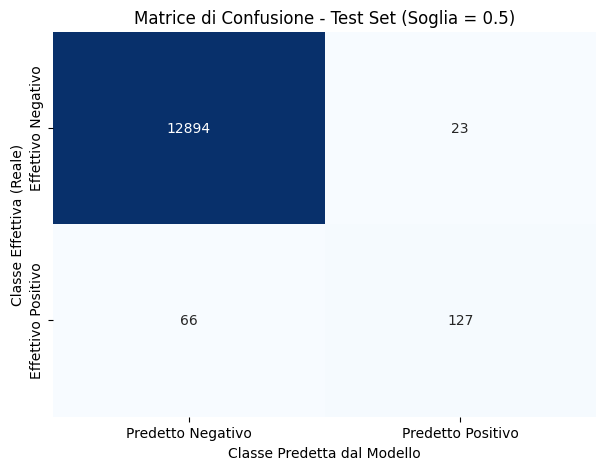

In [19]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# PREPARAZIONE DEL TEST SET
# Dobbiamo aggiungere la costante (intercetta) anche a X_test per allinearlo al modello stimato
X_test_with_const = sm.add_constant(X_test)

# PREVISIONE DELLE PROBABILITÀ DI DEFAULT (PD)
# Generiamo le probabilità out-of-sample usando il Test Set
y_probs_test = results.predict(X_test_with_const)

# Definizione della soglia convenzionale
threshold_0_5 = 0.5

# CLASSIFICAZIONE BINARIA
# Se la PD è >= 0.5 l'azienda viene classificata in default (1), altrimenti sana (0)
y_pred_0_5 = (y_probs_test >= threshold_0_5).astype(int)

# CALCOLO DELLA MATRICE DI CONFUSIONE (sul Test Set)
conf_matrix_0_5 = confusion_matrix(y_test, y_pred_0_5)

print(f"=== MATRICE DI CONFUSIONE SUL TEST SET (Soglia Standard = {threshold_0_5}) ===")
print(conf_matrix_0_5)
print("-" * 60)

# VISUALIZZAZIONE GRAFICA
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_0_5, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predetto Negativo', 'Predetto Positivo'],
            yticklabels=['Effettivo Negativo', 'Effettivo Positivo'])

plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Effettiva (Reale)')
plt.title(f'Matrice di Confusione - Test Set (Soglia = {threshold_0_5})')
plt.show()

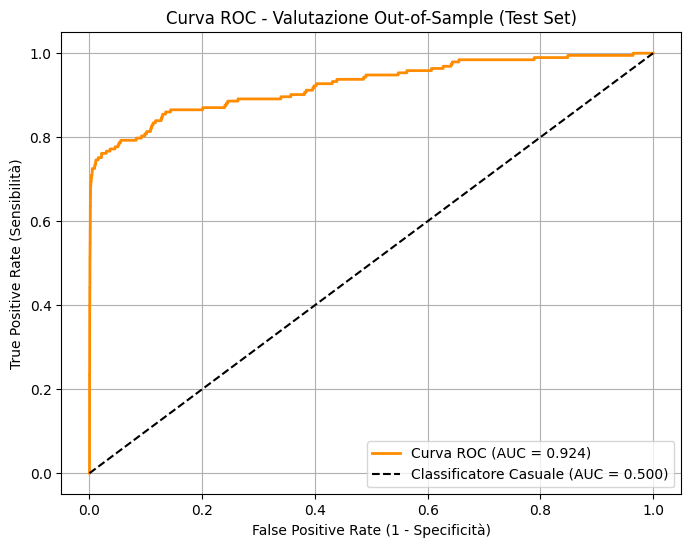

Il valore dell'AUC sul Test Set è: 0.9240


In [20]:
from sklearn.metrics import roc_curve, auc

# CALCOLO DELLA CURVA ROC E DELL'AUC (SUL TEST SET)

# Calcoliamo i punti della curva ROC usando i dati reali del Test Set e le probabilità previste
fpr, tpr, thresholds = roc_curve(y_test, y_probs_test)
roc_auc = auc(fpr, tpr)

# Generazione del grafico
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Classificatore Casuale (AUC = 0.500)')
plt.xlabel('False Positive Rate (1 - Specificità)')
plt.ylabel('True Positive Rate (Sensibilità)')
plt.title('Curva ROC - Valutazione Out-of-Sample (Test Set)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Il valore dell'AUC sul Test Set è: {roc_auc:.4f}")

=== OTTIMIZZAZIONE STATISTICA: INDICE DI YOUDEN ===
Soglia Ottimale (Cutoff) basata su Youden's J: 0.0243
Massimo valore di J raggiunto: 0.7402
------------------------------------------------------------


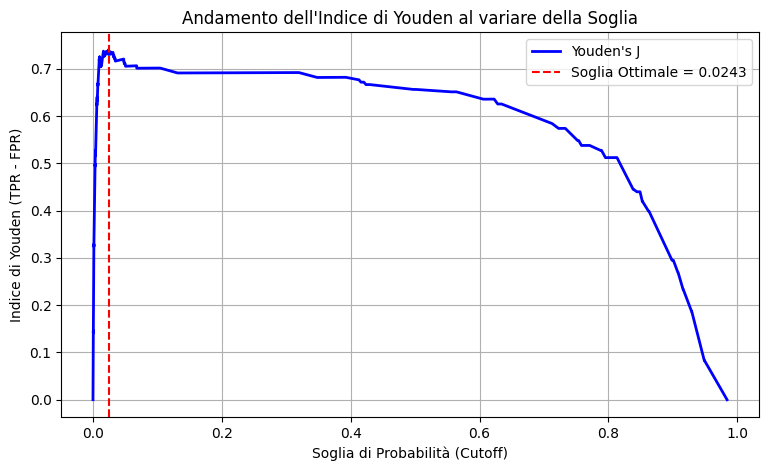

In [21]:
import numpy as np

# CALCOLO DELLA SOGLIA OTTIMALE TRAMITE INDICE DI YOUDEN (J)

# Calcolo della statistica Youden's J per ogni soglia: J = Sensibilità + Specificità - 1
# Che equivale a: J = TPR - FPR
youden_j = tpr - fpr

# Trovare l'indice del valore massimo di J e la relativa soglia ottimale
idx_ottimo = np.argmax(youden_j)
optimal_threshold_youden = thresholds[idx_ottimo]

print("=== OTTIMIZZAZIONE STATISTICA: INDICE DI YOUDEN ===")
print(f"Soglia Ottimale (Cutoff) basata su Youden's J: {optimal_threshold_youden:.4f}")
print(f"Massimo valore di J raggiunto: {youden_j[idx_ottimo]:.4f}")
print("-" * 60)

# Grafico: escludiamo la prima soglia fittizia (> 1) per una visualizzazione pulita
filtro_soglie = thresholds <= 1.0

plt.figure(figsize=(9, 5))
plt.plot(thresholds[filtro_soglie], youden_j[filtro_soglie], color='blue', lw=2, label="Youden's J")
plt.axvline(x=optimal_threshold_youden, color='red', linestyle='--',
            label=f'Soglia Ottimale = {optimal_threshold_youden:.4f}')

plt.xlabel('Soglia di Probabilità (Cutoff)')
plt.ylabel("Indice di Youden (TPR - FPR)")
plt.title("Andamento dell'Indice di Youden al variare della Soglia")
plt.legend()
plt.grid(True)
plt.show()

=== MATRICE DI CONFUSIONE SUL TEST SET ===
Soglia Ottimale di Youden applicata: 0.0243

[[12640   277]
 [   46   147]]
------------------------------------------------------------


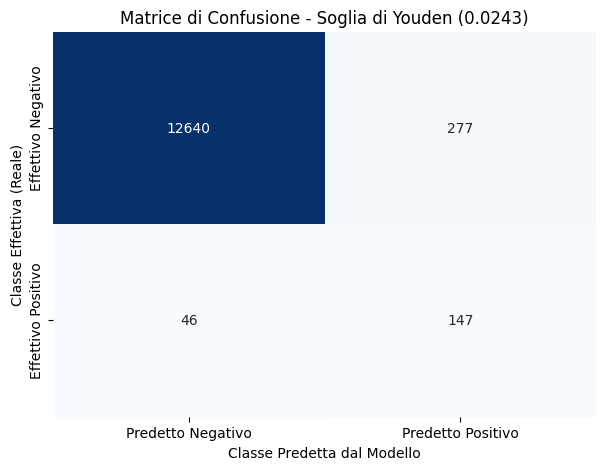

In [22]:
# MATRICE DI CONFUSIONE CON SOGLIA OTTIMALE DI YOUDEN (SUL TEST SET)

# Convertiamo le probabilità del TEST SET in classificazioni binarie usando la soglia di Youden
y_pred_optimal_threshold = (y_probs_test >= optimal_threshold_youden).astype(int)

# Calcolo della matrice di confusione utilizzando i dati reali di Test
conf_matrix_optimal_threshold = confusion_matrix(y_test, y_pred_optimal_threshold)

# Visualizzazione dei risultati testuali
print(f"=== MATRICE DI CONFUSIONE SUL TEST SET ===")
print(f"Soglia Ottimale di Youden applicata: {optimal_threshold_youden:.4f}\n")
print(conf_matrix_optimal_threshold)
print("-" * 60)

# Generazione del grafico con le etichette in italiano (Positivo/Negativo)
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_optimal_threshold, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predetto Negativo', 'Predetto Positivo'],
            yticklabels=['Effettivo Negativo', 'Effettivo Positivo'])

plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Effettiva (Reale)')
plt.title(f'Matrice di Confusione - Soglia di Youden ({optimal_threshold_youden:.4f})')
plt.show()

=== CONFRONTO DELLE PERFORMANCE (OUT-OF-SAMPLE SUL TEST SET) ===
AUROC Lasso Regression: 0.9238
AUROC Standard Logit:    0.9240

------------------------------------------------------------


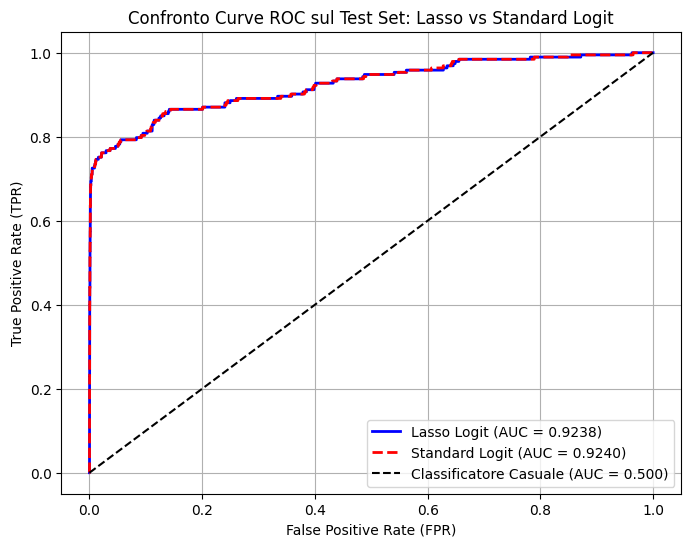


=== COEFFICIENTI DEL MODELLO LASSO (SELEZIONE DELLE VARIABILI) ===
Costante (Intercept)        : 0.2387
LN_TOTAL_ASSETS_t3          : -0.6860
Current_liabilities/Tot_ass._t3: -0.0699
Solvency_ratio_t3           : -0.0213
Debt/EBITDA_ratio_t3        : -0.0098
Total_assets_turnover_(times)_t3: -0.3122
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3: 0.0027
Return_on_asset_(ROA)_t3    : -0.0972
Current_ratio_t3            : -0.2446
LN_No_of_shareholders_t3    : 0.0605
Independence_t3_B           : 2.0378
Independence_t3_C           : 3.0985
Independence_t3_D           : 2.3531
Independence_t3_Missing     : 8.7520
Area_Center                 : 0.3969
Area_South                  : 0.4629
------------------------------------------------------------
Il modello LASSO ha ridotto a zero il coefficiente di 0 variabili.


In [23]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_curve, auc, roc_auc_score

# STIMA DEL MODELLO PENALIZZATO (LASSO) E CONFRONTO OUT-OF-SAMPLE

# Preparazione delle matrici senza la costante (scikit-learn la gestisce internamente)
X_train_lasso = X_train.drop(columns=['const']) if 'const' in X_train.columns else X_train
X_test_lasso = X_test.drop(columns=['const']) if 'const' in X_test.columns else X_test

# Addestramento del modello LASSO tramite Cross-Validation sul Training Set
lasso_logit_model = LogisticRegressionCV(
    cv=10,                      # 10-Fold Cross-Validation
    penalty='l1',               # Regolarizzazione L1 (LASSO)
    solver='liblinear',
    fit_intercept=True,         # Intercetta non penalizzata
    random_state=42,
    scoring='roc_auc',          # Ottimizzazione basata sull'AUC
    max_iter=10000
)
lasso_logit_model.fit(X_train_lasso, y_train)

# Generazione delle probabilità previste SUL TEST SET per entrambi i modelli
# Probabilità per il LASSO
y_probs_lasso_test = lasso_logit_model.predict_proba(X_test_lasso)[:, 1]

# Probabilità per il Logit Standard (usando l'oggetto 'results' e X_test con la costante)
X_test_with_const = sm.add_constant(X_test_lasso)
y_probs_logit_test = results.predict(X_test_with_const)

# Calcolo delle metriche AUC sul Test Set
auroc_lasso = roc_auc_score(y_test, y_probs_lasso_test)
auroc_logit = roc_auc_score(y_test, y_probs_logit_test)

print("=== CONFRONTO DELLE PERFORMANCE (OUT-OF-SAMPLE SUL TEST SET) ===")
print(f"AUROC Lasso Regression: {auroc_lasso:.4f}")
print(f"AUROC Standard Logit:    {auroc_logit:.4f}\n")
print("-" * 60)

# Calcolo e visualizzazione delle Curve ROC a confronto
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_probs_lasso_test)
fpr_logit, tpr_logit, _ = roc_curve(y_test, y_probs_logit_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, label=f'Lasso Logit (AUC = {auroc_lasso:.4f})', color='blue', lw=2)
plt.plot(fpr_logit, tpr_logit, label=f'Standard Logit (AUC = {auroc_logit:.4f})', color='red', linestyle='--', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Classificatore Casuale (AUC = 0.500)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Confronto Curve ROC sul Test Set: Lasso vs Standard Logit')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Visualizzazione dei coefficienti stimati dal LASSO (Selezione Variabili)
print("\n=== COEFFICIENTI DEL MODELLO LASSO (SELEZIONE DELLE VARIABILI) ===")
print(f"{'Costante (Intercept)':28}: {lasso_logit_model.intercept_[0]:.4f}")

variabili_eliminate = 0
for feature, coef in zip(X_train_lasso.columns, lasso_logit_model.coef_[0]):
    if coef == 0:
        print(f"{feature:28}: {coef:.4f}  <-- ELEMENTO ESCLUSO DALLA PENALIZZAZIONE")
        variabili_eliminate += 1
    else:
        print(f"{feature:28}: {coef:.4f}")

print("-" * 60)
print(f"Il modello LASSO ha ridotto a zero il coefficiente di {variabili_eliminate} variabili.")

=== OTTIMIZZAZIONE SOGLIA PER MODELLO LASSO (OUT-OF-SAMPLE) ===
Soglia Ottimale Youden (Lasso): 0.0242
Massimo valore Indice J:        0.7402
------------------------------------------------------------

Matrice di Confusione (Lasso - Soglia Youden sul Test Set):
[[12640   277]
 [   46   147]]
------------------------------------------------------------


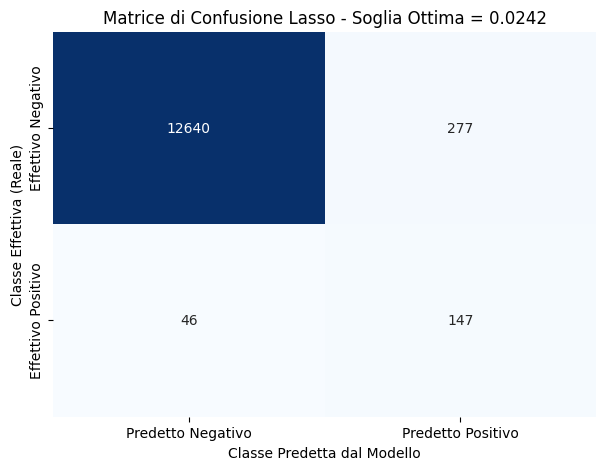

In [24]:
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# SOGLIA DI YOUDEN E MATRICE DI CONFUSIONE PER IL LASSO (SUL TEST SET)

# Usiamo le probabilità del TEST SET calcolate nella cella precedente per il LASSO
# Nota: l'oggetto 'y_probs_lasso_test' è stato generato a partire da X_test_lasso
fpr_lasso, tpr_lasso, thresholds_lasso = roc_curve(y_test, y_probs_lasso_test)

# Calcolo dell'indice Youden's J sul campione di Test
youden_j_lasso = tpr_lasso - fpr_lasso
idx_opt_lasso = np.argmax(youden_j_lasso)
opt_threshold_lasso = thresholds_lasso[idx_opt_lasso]

print("=== OTTIMIZZAZIONE SOGLIA PER MODELLO LASSO (OUT-OF-SAMPLE) ===")
print(f"Soglia Ottimale Youden (Lasso): {opt_threshold_lasso:.4f}")
print(f"Massimo valore Indice J:        {youden_j_lasso[idx_opt_lasso]:.4f}")
print("-" * 60)

# Classificazione binaria delle imprese del Test Set usando la soglia del Lasso
y_pred_youden_lasso = (y_probs_lasso_test >= opt_threshold_lasso).astype(int)

# 4. Calcolo della matrice di confusione finale (reale vs predetto sul Test Set)
conf_matrix_lasso = confusion_matrix(y_test, y_pred_youden_lasso)

print("\nMatrice di Confusione (Lasso - Soglia Youden sul Test Set):")
print(conf_matrix_lasso)
print("-" * 60)

# Visualizzazione grafica
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_lasso, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predetto Negativo', 'Predetto Positivo'],
            yticklabels=['Effettivo Negativo', 'Effettivo Positivo'])

plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Effettiva (Reale)')
plt.title(f'Matrice di Confusione Lasso - Soglia Ottima = {opt_threshold_lasso:.4f}')
plt.show()

In [25]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# STIMA DEL MODELLO RIDGE (PENALIZZAZIONE L2) SUL TRAINING SET

# Prepariamo i dati senza la costante (gestita internamente da scikit-learn)
X_train_ridge = X_train.drop(columns=['const']) if 'const' in X_train.columns else X_train
X_test_ridge = X_test.drop(columns=['const']) if 'const' in X_test.columns else X_test

# Addestramento del modello Ridge tramite 10-Fold CV sul Training Set
ridge_logit_model = LogisticRegressionCV(
    cv=10,                      # 10-Fold Cross-Validation
    penalty='l2',               # Regolarizzazione L2 (RIDGE)
    solver='liblinear',
    scoring='roc_auc',          # Ottimizzazione basata sull'AUC
    fit_intercept=True,
    random_state=42,
    max_iter=10000
)
ridge_logit_model.fit(X_train_ridge, y_train)

# Generazione delle probabilità previste SUL TEST SET
y_probs_ridge_test = ridge_logit_model.predict_proba(X_test_ridge)[:, 1]

# Calcolo dell'AUC out-of-sample
auroc_ridge = roc_auc_score(y_test, y_probs_ridge_test)

print("=== RISULTATI RIDGE REGRESSION (OUT-OF-SAMPLE) ===")
print(f"Miglior parametro C trovato (1/lambda): {ridge_logit_model.C_[0]:.6f}")
print(f"AUC Ridge Regression sul Test Set:    {auroc_ridge:.4f}")
print("-" * 60)

# Visualizzazione e confronto dei coefficienti Ridge
print("\n=== COEFFICIENTI DEL MODELLO RIDGE ===")
print(f"{'Costante (Intercept)':28}: {ridge_logit_model.intercept_[0]:.4f}")
for feature, coef in zip(X_train_ridge.columns, ridge_logit_model.coef_[0]):
    print(f"{feature:28}: {coef:.4f}")

=== RISULTATI RIDGE REGRESSION (OUT-OF-SAMPLE) ===
Miglior parametro C trovato (1/lambda): 1291.549665
AUC Ridge Regression sul Test Set:    0.9250
------------------------------------------------------------

=== COEFFICIENTI DEL MODELLO RIDGE ===
Costante (Intercept)        : 1.6685
LN_TOTAL_ASSETS_t3          : -0.7271
Current_liabilities/Tot_ass._t3: -0.1421
Solvency_ratio_t3           : -0.0210
Debt/EBITDA_ratio_t3        : -0.0105
Total_assets_turnover_(times)_t3: -0.3324
Durata_media_dei_crediti_al_lordo_IVA_(days)_t3: 0.0026
Return_on_asset_(ROA)_t3    : -0.0969
Current_ratio_t3            : -0.2609
LN_No_of_shareholders_t3    : 0.0276
Independence_t3_B           : 1.1412
Independence_t3_C           : 2.1656
Independence_t3_D           : 1.4531
Independence_t3_Missing     : 7.8702
Area_Center                 : 0.3895
Area_South                  : 0.4498


=== OTTIMIZZAZIONE SOGLIA PER MODELLO RIDGE (OUT-OF-SAMPLE) ===
Soglia Ottimale Youden (Ridge): 0.0240
Massimo valore Indice J:        0.7392
------------------------------------------------------------

Matrice di Confusione (Ridge - Soglia Youden sul Test Set):
[[12627   290]
 [   46   147]]
------------------------------------------------------------


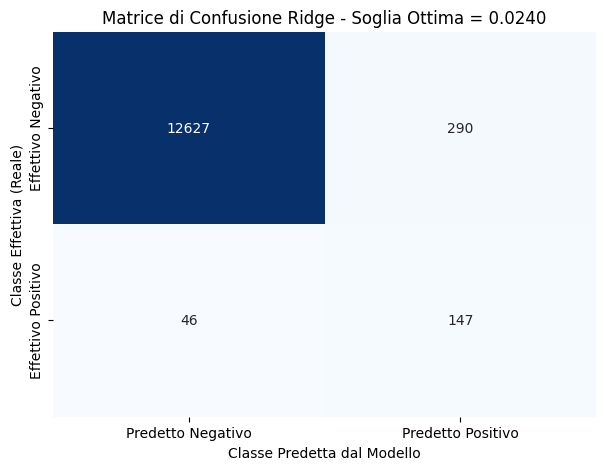

In [26]:
from sklearn.metrics import roc_curve, confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# SOGLIA DI YOUDEN E MATRICE DI CONFUSIONE PER LA RIDGE (SUL TEST SET)

# Usiamo le probabilità del TEST SET calcolate nella cella precedente per la RIDGE
# Nota: l'oggetto 'y_probs_ridge_test' è stato generato a partire da X_test_ridge
fpr_ridge, tpr_ridge, thresholds_ridge = roc_curve(y_test, y_probs_ridge_test)

# Calcolo dell'indice Youden's J sul campione di Test
youden_j_ridge = tpr_ridge - fpr_ridge
idx_opt_ridge = np.argmax(youden_j_ridge)
opt_threshold_ridge = thresholds_ridge[idx_opt_ridge]

print("=== OTTIMIZZAZIONE SOGLIA PER MODELLO RIDGE (OUT-OF-SAMPLE) ===")
print(f"Soglia Ottimale Youden (Ridge): {opt_threshold_ridge:.4f}")
print(f"Massimo valore Indice J:        {youden_j_ridge[idx_opt_ridge]:.4f}")
print("-" * 60)

# Classificazione binaria delle imprese del Test Set usando la soglia della Ridge
y_pred_youden_ridge = (y_probs_ridge_test >= opt_threshold_ridge).astype(int)

# Calcolo della matrice di confusione finale (reale vs predetto sul Test Set)
conf_matrix_ridge = confusion_matrix(y_test, y_pred_youden_ridge)

print("\nMatrice di Confusione (Ridge - Soglia Youden sul Test Set):")
print(conf_matrix_ridge)
print("-" * 60)

# Visualizzazione grafica
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_ridge, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predetto Negativo', 'Predetto Positivo'],
            yticklabels=['Effettivo Negativo', 'Effettivo Positivo'])

plt.xlabel('Classe Predetta dal Modello')
plt.ylabel('Classe Effettiva (Reale)')
plt.title(f'Matrice di Confusione Ridge - Soglia Ottima = {opt_threshold_ridge:.4f}')
plt.show()

=== OTTIMIZZAZIONE DELLA SOGLIA OPERATIVA ===
Theta (θ)  | Soglia Ottimale (z*) | Loss Minima 
--------------------------------------------------
0.3        | 0.0098               | 0.1375      
0.5        | 0.0243               | 0.1299      
0.7        | 0.0311               | 0.0842      


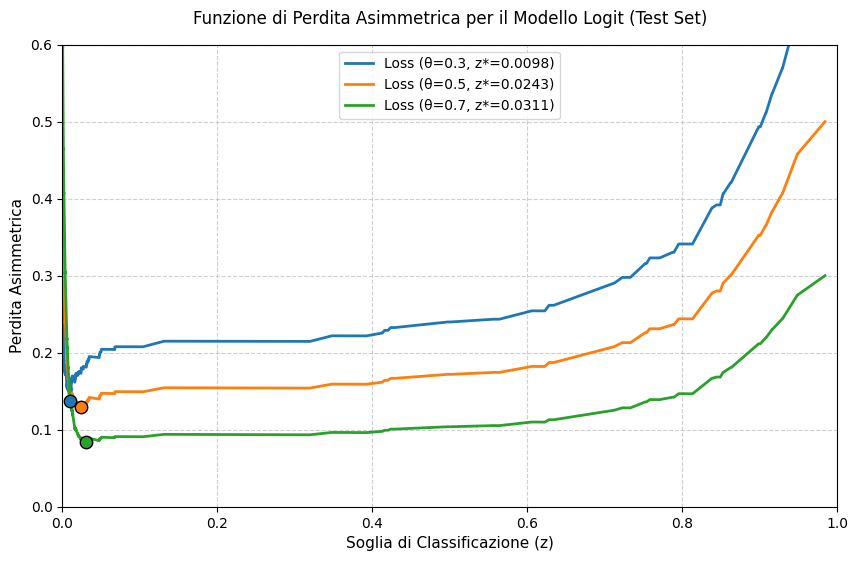

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# FUNZIONE DI PERDITA ASIMMETRICA SUL TEST SET (MODELLO LOGIT STANDARD)

# Ricalcoliamo i vettori ROC sul Test Set per il Logit Standard di base
fpr_logit, tpr_logit, thresholds_logit = roc_curve(y_test, y_probs_test)

# Calcolo del FNR (Tasso di Falsi Negativi)
fnr_logit = 1 - tpr_logit

# DEFINIZIONE DELLA FUNZIONE DI PERDITA ASIMMETRICA
def asymmetric_loss(fpr, fnr, theta):
    return theta * fpr + (1 - theta) * fnr

# VALUTAZIONE E GRAFICO PER DIVERSI THETA (0.3, 0.5, 0.7)
thetas = [0.3, 0.5, 0.7]
plt.figure(figsize=(10, 6))

print(f"=== OTTIMIZZAZIONE DELLA SOGLIA OPERATIVA ===")
print(f"{'Theta (θ)':<10} | {'Soglia Ottimale (z*)':<20} | {'Loss Minima':<12}")
print("-" * 50)

for t in thetas:
    # Calcolo della perdita per tutte le soglie (escludendo la prima fittizia > 1)
    loss_values = asymmetric_loss(fpr_logit[1:], fnr_logit[1:], t)
    clean_thresholds = thresholds_logit[1:]

    # Trovare l'indice del valore minimo della perdita
    idx_min = np.argmin(loss_values)
    z_star = clean_thresholds[idx_min]
    min_loss = loss_values[idx_min]

    print(f"{t:<10} | {z_star:<20.4f} | {min_loss:<12.4f}")

    # Visualizzazione della curva di perdita per questo specifico Theta
    plt.plot(clean_thresholds, loss_values, label=f'Loss (θ={t}, z*={z_star:.4f})', lw=2)
    plt.scatter(z_star, min_loss, s=80, edgecolors='k', zorder=5)

# Configurazione e formattazione del grafico
plt.xlim(0, 1)
plt.ylim(0, 0.6)  # Ottimizzato per concentrarsi sulla zona di minimo delle curve
plt.xlabel('Soglia di Classificazione (z)', fontsize=11)
plt.ylabel('Perdita Asimmetrica', fontsize=11)
plt.title('Funzione di Perdita Asimmetrica per il Modello Logit (Test Set)', fontsize=12, pad=15)
plt.legend(loc="upper center")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

=== OTTIMIZZAZIONE DELLA SOGLIA OPERATIVA (RIDGE) ===
Theta (θ)  | Soglia Ottimale (z*) | Loss Minima 
--------------------------------------------------
0.3        | 0.0101               | 0.1385      
0.5        | 0.0240               | 0.1304      
0.7        | 0.0312               | 0.0841      


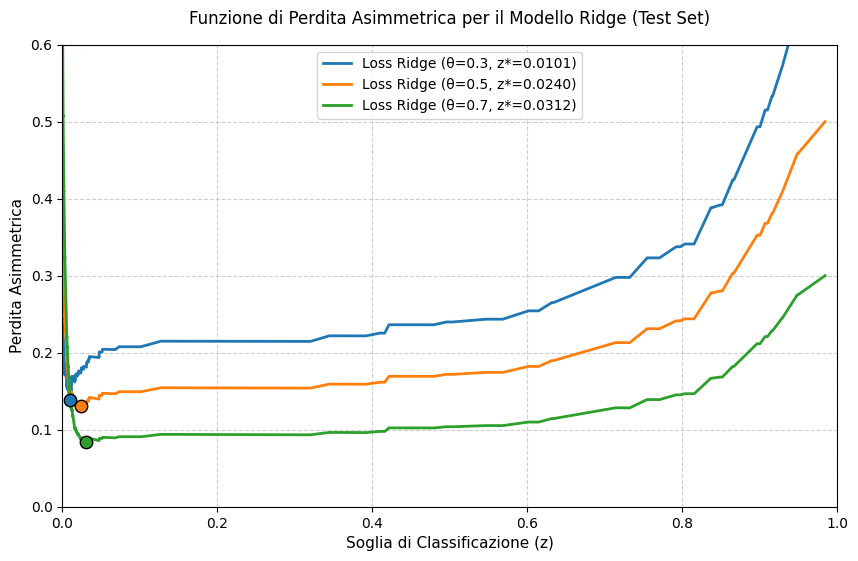

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# FUNZIONE DI PERDITA ASIMMETRICA SUL TEST SET (MODELLO RIDGE)

# Ricalcoliamo i vettori ROC sul Test Set usando le probabilità della RIDGE
fpr_ridge, tpr_ridge, thresholds_ridge = roc_curve(y_test, y_probs_ridge_test)

# Calcolo del FNR (Tasso di Falsi Negativi) per la Ridge
fnr_ridge = 1 - tpr_ridge

# DEFINIZIONE DELLA FUNZIONE DI PERDITA ASIMMETRICA
def asymmetric_loss(fpr, fnr, theta):
    return theta * fpr + (1 - theta) * fnr

# VALUTAZIONE E GRAFICO PER DIVERSI THETA (0.3, 0.5, 0.7)
thetas = [0.3, 0.5, 0.7]
plt.figure(figsize=(10, 6))

print(f"=== OTTIMIZZAZIONE DELLA SOGLIA OPERATIVA (RIDGE) ===")
print(f"{'Theta (θ)':<10} | {'Soglia Ottimale (z*)':<20} | {'Loss Minima':<12}")
print("-" * 50)

for t in thetas:
    # Calcolo della perdita per tutte le soglie (escludendo la prima fittizia > 1)
    loss_values = asymmetric_loss(fpr_ridge[1:], fnr_ridge[1:], t)
    clean_thresholds = thresholds_ridge[1:]

    # Trovare l'indice del valore minimo della perdita
    idx_min = np.argmin(loss_values)
    z_star = clean_thresholds[idx_min]
    min_loss = loss_values[idx_min]

    print(f"{t:<10} | {z_star:<20.4f} | {min_loss:<12.4f}")

    # Visualizzazione della curva di perdita per questo specifico Theta
    plt.plot(clean_thresholds, loss_values, label=f'Loss Ridge (θ={t}, z*={z_star:.4f})', lw=2)
    plt.scatter(z_star, min_loss, s=80, edgecolors='k', zorder=5)

# 4. Configurazione e formattazione del grafico
plt.xlim(0, 1)
plt.ylim(0, 0.6)
plt.xlabel('Soglia di Classificazione (z)', fontsize=11)
plt.ylabel('Perdita Asimmetrica', fontsize=11)
plt.title('Funzione di Perdita Asimmetrica per il Modello Ridge (Test Set)', fontsize=12, pad=15)
plt.legend(loc="upper center")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report

# STIMA DEL MODELLO XGBOOST SUL TRAINING SET E VALUTAZIONE SUL TEST SET

# Prepariamo i dati senza la costante (Nota: XGBoost non richiede la costante esplicita)
X_train_xgb = X_train.drop(columns=['const']) if 'const' in X_train.columns else X_train
X_test_xgb = X_test.drop(columns=['const']) if 'const' in X_test.columns else X_test

# Inizializzazione e Addestramento del modello XGBoost
# Nota: Impostiamo iperparametri robusti per evitare l'overfitting su dati sbilanciati
xgb_model = XGBClassifier(
    n_estimators=500,           # Numero di alberi decisionali
    max_depth=4,                # Profondità massima dell'albero (bassa per evitare overfitting)
    learning_rate=0.05,         # Passo di apprendimento (shrinkage)
    subsample=0.8,              # Percentuale di osservazioni campionate per ogni albero
    colsample_bytree=0.8,       # Percentuale di variabili campionate per ogni albero
    scale_pos_weight=1,         # Gestito tramite soglia asimmetrica (Youden) successivamente
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_xgb, y_train)

# Generazione delle probabilità previste SUL TEST SET
y_probs_xgb_test = xgb_model.predict_proba(X_test_xgb)[:, 1]

# Calcolo dell'AUC out-of-sample
auroc_xgb = roc_auc_score(y_test, y_probs_xgb_test)

print("=== RISULTATI XGBOOST REGRESSION (OUT-OF-SAMPLE) ===")
print(f"AUC XGBoost sul Test Set:    {auroc_xgb:.4f}")
print("-" * 60)


# Impostiamo la dimensione del grafico
plt.figure(figsize=(10, 7))

# Plot della curva ROC per il Lasso (Rosso - Tratteggiato)
plt.plot(fpr_lasso, tpr_lasso, label='Lasso Logit (AUC = 0.9238)', color='red', lw=2, linestyle='--')

# Plot della curva ROC per il Logit Standard (Giallo - Tratteggiato)
plt.plot(fpr_logit, tpr_logit, label='Standard Logit (AUC = 0.9240)', color='gold', lw=2, linestyle='--')

# Plot della curva ROC per la Ridge (Verde - Tratteggiato)
plt.plot(fpr_ridge, tpr_ridge, label='Ridge Logit (AUC = 0.9250)', color='green', lw=2, linestyle='--')

# Plot della curva ROC per XGBoost (Rosa scuro - Linea Continua)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auroc_xgb:.4f})', color='deeppink', lw=2.5)

# Plot della linea del Classificatore Casuale (Nera e tratteggiata)
plt.plot([0, 1], [0, 1], color='black', lw=1.5, linestyle='--', label='Classificatore Casuale (AUC = 0.500)')

# Configurazione formattazione assi e griglia
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Confronto Curve ROC sul Test Set', fontsize=13)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True)

# Mostra il grafico
plt.tight_layout()
plt.show()

NameError: name 'X_train' is not defined

In [2]:
# SOGLIA DI YOUDEN PER XGBOOST

# Calcoliamo i vettori della curva ROC (FPR, TPR e le relative soglie)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_probs_xgb_test)

# Calcoliamo l'indice di Youden (Sensibilità + Specificità - 1)
youden_j_xgb = tpr_xgb - fpr_xgb

# Troviamo la posizione del valore massimo e la soglia corrispondente
idx_opt_xgb = np.argmax(youden_j_xgb)
opt_threshold_xgb = thresholds_xgb[idx_opt_xgb]
max_youden_j = youden_j_xgb[idx_opt_xgb]

# Plot grafico
plt.figure(figsize=(10, 5.5))

# Curva dell'indice di Youden in viola
plt.plot(thresholds_xgb[1:], youden_j_xgb[1:], color='purple', lw=2.5, label="Youden's J")

# Linea verticale tratteggiata ROSSA in corrispondenza della soglia ottima
plt.axvline(x=opt_threshold_xgb, color='red', linestyle='--', lw=2,
            label=f'Soglia Ottimale = {opt_threshold_xgb:.4f}')

# Configurazione assi e griglia
plt.xlim([-0.05, 1.05])
plt.xlabel('Soglia di Probabilità (Cutoff)', fontsize=11)
plt.ylabel('Indice di Youden (TPR - FPR)', fontsize=11)
plt.title("Andamento dell'Indice di Youden al variare della Soglia (XGBoost)", fontsize=13)
plt.legend(loc="upper right", fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

print("=== VALORI RILEVATI ===")
print(f"Soglia Ottimale XGBoost: {opt_threshold_xgb:.4f}")
print(f"Indice J Massimo:         {max_youden_j:.4f}")

NameError: name 'y_test' is not defined

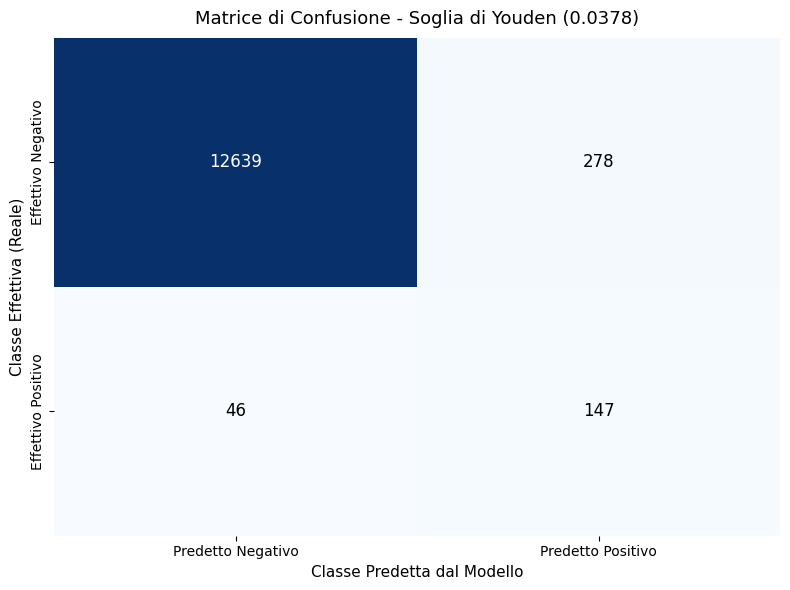

=== METRICHE OPERATIVE DI XGBOOST ===
Accuratezza Complessiva:   0.9753
Sensibilità (TPR):          0.7617  -> (Default intercettati: 147 su 193)
Specificità (TNR):          0.9785  -> (Sane confermate:      12639 su 12917)
Tasso Falsi Allarmi (FPR):  0.0215  -> (Sane bloccate:        278)


In [32]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Applichiamo la soglia ottima calcolata (0.0378) alle probabilità del Test Set
y_pred_xgb = (y_probs_xgb_test >= opt_threshold_xgb).astype(int)

# Generiamo la matrice di confusione numerica
cm_xgb = confusion_matrix(y_test, y_pred_xgb)


# PLOT DELLA MATRICE DI CONFUSIONE PER XGBOOST

plt.figure(figsize=(8, 6))

# Creiamo l'heatmap replicando lo stile blu (cmap='Blues') e togliendo la colorbar
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predetto Negativo', 'Predetto Positivo'],
            yticklabels=['Effettivo Negativo', 'Effettivo Positivo'],
            annot_kws={'size': 12, 'color': 'black'})

# Poiché seaborn colora il testo in automatico, forziamo il testo della cella in alto a sinistra
# ad essere bianco se lo sfondo diventa troppo scuro
ax = plt.gca()
for text in ax.texts:
    # Se il valore è quello della cella TN (molto alto), lo coloriamo di bianco
    if int(text.get_text()) == cm_xgb[0, 0]:
        text.set_color('white')

# Configurazione titoli ed etichette assi
plt.title('Matrice di Confusione - Soglia di Youden (0.0378)', fontsize=13, pad=10)
plt.ylabel('Classe Effettiva (Reale)', fontsize=11)
plt.xlabel('Classe Predetta dal Modello', fontsize=11)

# Sistemazione del layout
plt.tight_layout()
plt.show()


# REPORT METRICHE IN CONSOLE

TN, FP, FN, TP = cm_xgb.ravel()
sensibilita = TP / (TP + FN)
specificita = TN / (TN + FP)
accuratezza = (TP + TN) / (TP + TN + FP + FN)

print("=== METRICHE OPERATIVE DI XGBOOST ===")
print(f"Accuratezza Complessiva:   {accuratezza:.4f}")
print(f"Sensibilità (TPR):          {sensibilita:.4f}  -> (Default intercettati: {TP} su {TP+FN})")
print(f"Specificità (TNR):          {specificita:.4f}  -> (Sane confermate:      {TN} su {TN+FP})")
print(f"Tasso Falsi Allarmi (FPR):  {1 - specificita:.4f}  -> (Sane bloccate:        {FP})")
print("=====================================")

Calcolo dei valori SHAP


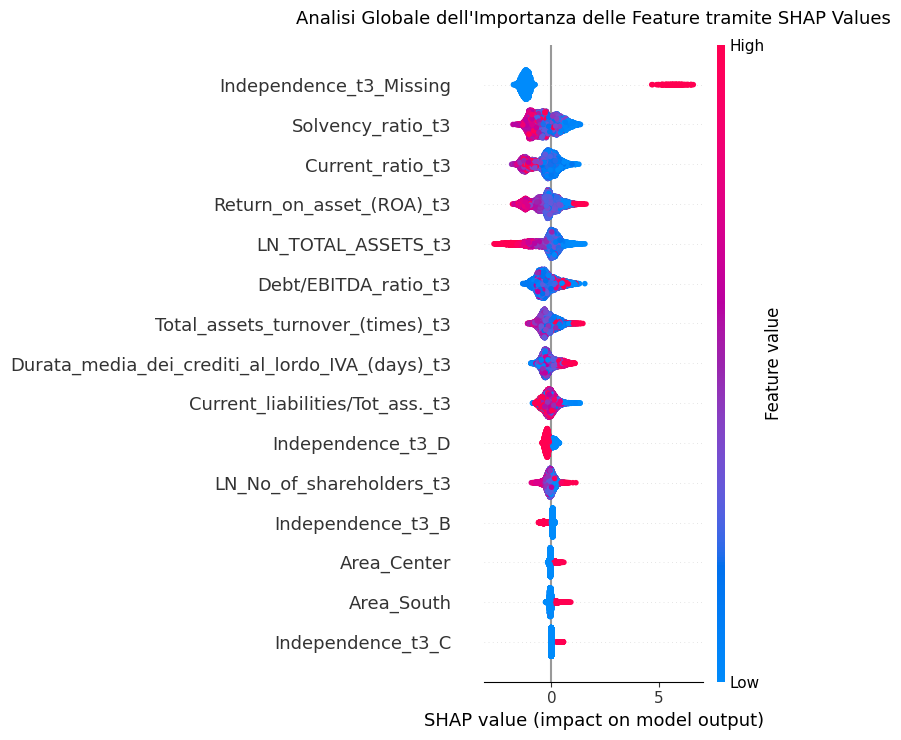

In [33]:
import shap

# Creiamo l'oggetto Explainer specifico per modelli ad albero come XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Calcoliamo i valori SHAP sul Test Set (senza costante)
shap_values = explainer(X_test_xgb)

print("Calcolo dei valori SHAP")

# Generiamo il Summary Plot di SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_xgb, show=False)

# Configuriamo il titolo
plt.title("Analisi Globale dell'Importanza delle Feature tramite SHAP Values", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

In [34]:
# ==========================================
# SHAP INTERACTION VALUES
# ==========================================

import numpy as np
import pandas as pd
import shap

# TreeExplainer sul modello XGBoost già stimato
explainer_inter = shap.TreeExplainer(xgb_model)

# Calcolo degli SHAP interaction values sul test set
shap_interaction_values = explainer_inter.shap_interaction_values(X_test_xgb)

print("Shape interaction values:", np.array(shap_interaction_values).shape)

Shape interaction values: (13110, 15, 15)


In [35]:
# Valore assoluto medio dell'interazione per ciascuna coppia
mean_abs_interactions = np.abs(shap_interaction_values).mean(axis=0)

# Escludiamo la diagonale perché contiene i main effects
np.fill_diagonal(mean_abs_interactions, 0)

feature_names = X_test_xgb.columns

interaction_list = []

for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        interaction_list.append({
            "Variabile_1": feature_names[i],
            "Variabile_2": feature_names[j],
            "Mean_abs_SHAP_interaction": mean_abs_interactions[i, j]
        })

interaction_df = pd.DataFrame(interaction_list)

interaction_df = interaction_df.sort_values(
    "Mean_abs_SHAP_interaction",
    ascending=False
).reset_index(drop=True)

print("\nTOP 15 INTERAZIONI:")
print(interaction_df.head(15))


TOP 15 INTERAZIONI:
                         Variabile_1                       Variabile_2  \
0                  Solvency_ratio_t3  Total_assets_turnover_(times)_t3   
1                 LN_TOTAL_ASSETS_t3                 Solvency_ratio_t3   
2    Current_liabilities/Tot_ass._t3                  Current_ratio_t3   
3    Current_liabilities/Tot_ass._t3  Total_assets_turnover_(times)_t3   
4                   Current_ratio_t3           Independence_t3_Missing   
5                  Solvency_ratio_t3                  Current_ratio_t3   
6                 LN_TOTAL_ASSETS_t3          LN_No_of_shareholders_t3   
7                  Solvency_ratio_t3           Independence_t3_Missing   
8                  Solvency_ratio_t3          Return_on_asset_(ROA)_t3   
9                 LN_TOTAL_ASSETS_t3              Debt/EBITDA_ratio_t3   
10                LN_TOTAL_ASSETS_t3                  Current_ratio_t3   
11   Current_liabilities/Tot_ass._t3              Debt/EBITDA_ratio_t3   
12   Current_liab

In [ ]:
import matplotlib.pyplot as plt
import shap

# Impostiamo la dimensione del grafico
plt.figure(figsize=(8, 5.5))

# Generiamo il dependence plot inserendo le variabili
shap.dependence_plot(
    "Solvency_ratio_t3",
    shap_values.values,
    X_test_xgb,
    interaction_index="Current_ratio_t3",
    show=False
)

# Configurazione del titolo
plt.title("Analisi di Interazione Non Lineare: Solvibilità vs Liquidità", fontsize=13, pad=15)

# Ottimizzazione del layout e visualizzazione
plt.tight_layout()
plt.show()